In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "../raw_data/worldcover/ESA_WorldCover_10m_2021_v200_N06E027_Map.tif"

with rasterio.open(path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Width: 36000
Height: 36000
Bounds: BoundingBox(left=27.0, bottom=6.0, right=30.0, top=9.0)
NoData: 0.0


In [3]:
with rasterio.open(path) as src:
    data = src.read(1)

values, counts = np.unique(data, return_counts=True)

for value, count in zip(values, counts):
    print(f"Class {value}: {count:,} pixels")

Class 10: 198,252,523 pixels
Class 20: 385,166,763 pixels
Class 30: 553,571,995 pixels
Class 40: 3,766,299 pixels
Class 50: 613,177 pixels
Class 60: 409,626 pixels
Class 80: 977,359 pixels
Class 90: 153,242,258 pixels


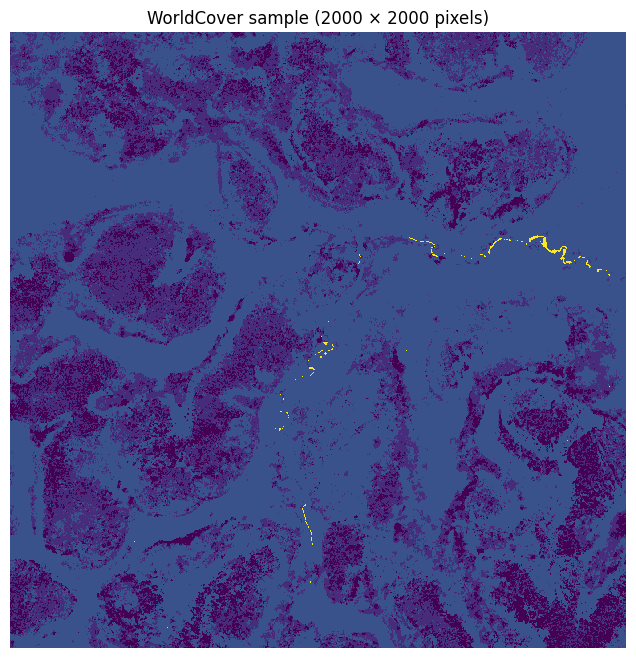

In [5]:
with rasterio.open(path) as src:
    # Take a 2000 x 2000 pixel window from the centre
    window = rasterio.windows.Window(
        src.width // 2 - 1000,
        src.height // 2 - 1000,
        2000,
        2000
    )

    sample = src.read(1, window=window)

plt.figure(figsize=(10, 8))
plt.imshow(sample, interpolation="none")
plt.title("WorldCover sample (2000 × 2000 pixels)")
plt.axis("off")
plt.show()